# 🏠 Housing Price Regression — End-to-End Modeling

This notebook documents the execution of a **leakage-free regression system** for predicting housing prices.

The objective of this project is **not model sophistication**, but:
- establishing a **correct baseline**
- enforcing **proper ML workflow discipline**
- validating performance against **trivial baselines**
- identifying **explicit failure modes** through residual analysis

All decisions prioritize **interpretability, correctness, and reviewability**.


## Project Setup and Imports

All preprocessing, modeling, and evaluation logic is implemented in the `src/` directory.

This notebook acts as an **execution and analysis layer only**.
No business logic is defined here.


In [1]:
import sys
from pathlib import Path

# The notebook is in the notebooks directory
# Project root is one level up
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR

# Add both root and src to path for imports
sys.path.insert(0, str(PROJECT_ROOT / "src"))
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
from sklearn.model_selection import train_test_split

from preprocessing import split_features_target
from pipeline import build_regression_pipeline
from evaluation import (
    evaluate_regression,
    baseline_predictors,
    plot_residuals
)

In [2]:
import sys
import importlib

# Clear any previously imported src modules
modules_to_remove = [m for m in sys.modules if 'preprocessing' in m or 'pipeline' in m or 'evaluation' in m]
for m in modules_to_remove:
    del sys.modules[m]

## Dataset Loading

The raw housing dataset is loaded without any preprocessing.
Preserving the raw data at this stage ensures a clean and traceable data flow.


In [3]:
df = pd.read_csv(PROJECT_ROOT / "data" / "raw" / "AmesHousing.csv")
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


## Target and Feature Specification

The target variable is the house price.

Features are explicitly divided into:
- numerical features (continuous or ordinal)
- categorical features (binary or nominal)

This separation is required for correct preprocessing and pipeline construction.


In [4]:
TARGET = "SalePrice"

numeric_features = [
    "Lot Area",
    "Overall Qual",
    "Overall Cond",
    "Year Built",
    "Year Remod/Add",
    "Mas Vnr Area",
    "BsmtFin SF 1",
    "BsmtFin SF 2",
    "Bsmt Unf SF",
    "Total Bsmt SF",
    "1st Flr SF",
    "2nd Flr SF",
    "Low Qual Fin SF",
    "Gr Liv Area",
    "Garage Cars",
    "Garage Area"
]

categorical_features = [
    "MS Zoning",
    "Street",
    "Lot Shape",
    "Land Contour",
    "Lot Config",
    "Land Slope",
    "Neighborhood",
    "Bldg Type",
    "House Style",
    "Heating",
    "Central Air",
    "Foundation"
]

## Train–Test Split

The dataset is split **before any preprocessing** to prevent data leakage.

All transformations are fit exclusively on training data through the pipeline.


In [5]:
X, y = split_features_target(df, TARGET)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


## Trivial Baseline Evaluation

Before fitting a regression model, trivial predictors are evaluated:
- Mean price predictor
- Median price predictor

Any trained model must outperform these baselines to be considered meaningful.


In [6]:
mean_baseline = baseline_predictors(y_train, strategy="mean")
median_baseline = baseline_predictors(y_train, strategy="median")

baseline_preds = {
    "Mean Baseline": [mean_baseline] * len(y_test),
    "Median Baseline": [median_baseline] * len(y_test)
}

for name, preds in baseline_preds.items():
    metrics = evaluate_regression(y_test, preds)
    print(name, metrics)


Mean Baseline {'MAE': 64611.411613705466, 'RMSE': np.float64(90222.37239996913), 'R2': -0.015282546687198861}
Median Baseline {'MAE': 63838.10068259386, 'RMSE': np.float64(94322.62486574918), 'R2': -0.10966066411249265}


## Model Construction

A linear regression model is used as the primary estimator.

The model is embedded inside a preprocessing pipeline that:
- scales numerical features
- encodes categorical features
- guarantees leakage-free execution

This pipeline defines the **entire modeling system**.


In [7]:
pipeline = build_regression_pipeline(
    numeric_features=numeric_features,
    categorical_features=categorical_features
)


## Model Training

The pipeline is trained using only the training split.

All preprocessing steps are fit internally as part of the pipeline.


In [8]:
pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

## Model Evaluation

The trained model is evaluated on the unseen test set.

Metrics are interpreted in comparison to trivial baselines rather than in isolation.


In [9]:
y_pred = pipeline.predict(X_test)

metrics = evaluate_regression(y_test, y_pred)
metrics


{'MAE': 18980.28288823707,
 'RMSE': np.float64(32042.207306114942),
 'R2': 0.8719430107689046}

## Residual Analysis

Residual diagnostics are used to identify:
- heteroscedasticity
- outliers
- systematic bias across prediction ranges

This analysis reveals model failure modes that metrics alone cannot capture.


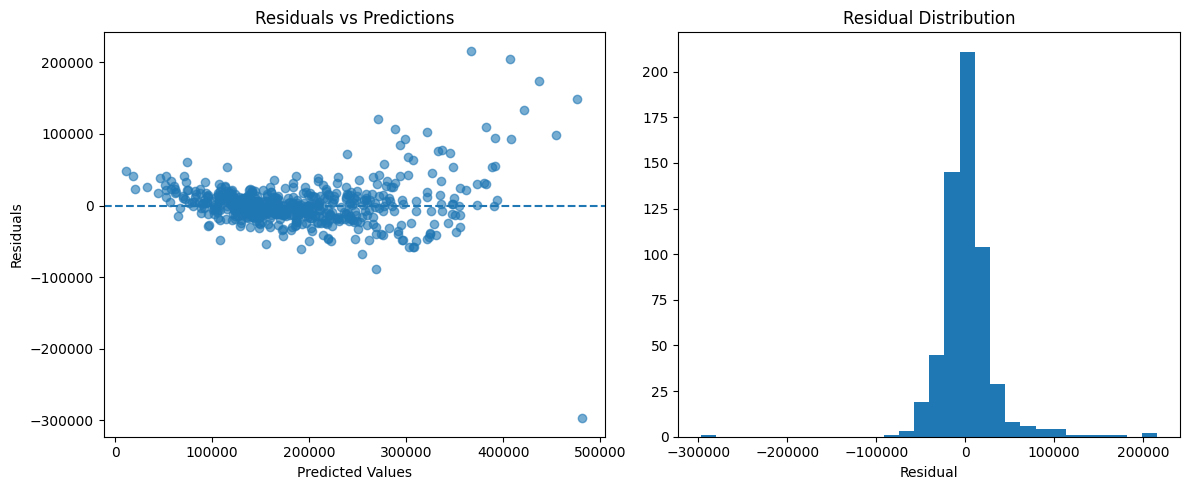

In [10]:
plot_residuals(y_test, y_pred)


## Observations and Failure Modes

From residual analysis, the following issues are observed:

- Error variance increases for higher-priced houses (heteroscedasticity)
- A small number of extreme outliers disproportionately affect RMSE
- Linear assumptions fail for certain feature interactions

These limitations are inherent to the model choice and are documented explicitly.


## Conclusion

This project demonstrates a **correct and interpretable regression baseline**.

Key outcomes:
- Linear regression outperforms trivial baselines
- Residual analysis exposes clear failure modes
- The model serves as a diagnostic foundation rather than a final solution

Future improvements should be driven by observed weaknesses, not default complexity.


## Notebook Philosophy

This notebook is intentionally:
- linear
- deterministic
- explanation-driven

All experimentation and learning artifacts are excluded by design.
